# Exploratory Data Analysis (EDA) - US Traffic Incident Analysis
บทสรุปการวิเคราะห์ข้อมูลอุบัติเหตุจราจรในสหรัฐอเมริกา เพื่อทำความเข้าใจพฤติกรรมของข้อมูล (Insights) ที่ส่งผลต่อความรุนแรง (Severity), ระยะเวลา (Duration) และระยะทาง (Distance) โดยผลลัพธ์จากส่วนนี้จะถูกนำไปใช้ในการทำ Feature Engineering และการออกแบบโมเดลทำนายผล

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting format
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_csv("../data/processed/01.3/train_advance_clean.csv")
print(f"Data loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

Data loaded: 5,469,092 rows, 40 columns


,Severity,Start_Time,Start_Lat,Start_Lng,Distance(mi),Description,Street,City,County,State,...,Traffic_Signal,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Duration(min),Start_Date,Hour,Month,Weather_Group
0,3,2016-11-08 08:50:37,29.718655,-95.321053,0.010,Accident on I-45 Northbound at I-45 Exits 43A ...,I-45 N,Houston,Harris,TX,...,True,Day,Day,Day,Day,29.116667,2016-11-08,8,11,Cloudy
1,2,2021-07-26 07:04:56,38.927551,-121.080093,0.000,Right hand shoulder blocked due to accident on...,Taylor Ln,Auburn,Placer,CA,...,False,Day,Day,Day,Day,46.600000,2021-07-26,7,7,Clear
2,2,2018-10-24 08:23:38,34.776241,-86.672829,0.000,Lane blocked due to accident on AL-255 Researc...,Highway 255,Huntsville,Madison,AL,...,False,Day,Day,Day,Day,29.650000,2018-10-24,8,10,Clear
3,3,2019-07-11 10:42:48,42.384880,-83.149467,0.600,Entry ramp to I-96 Westbound from Davison West...,Edward J Jeffries Fwy,Detroit,Wayne,MI,...,False,Day,Day,Day,Day,118.650000,2019-07-11,10,7,Clear
4,2,2020-11-06 01:29:00,33.776575,-117.837134,0.474,1023: NB 55 JNO 22. SV REAR ENDED VV AND WAS L...,Garden Grove Fwy,Orange,Orange,CA,...,False,Night,Night,Night,Night,140.533333,2020-11-06,1,11,Clear


# หมวดที่ 1: การวิเคราะห์ตัวแปรเป้าหมาย (Target Variables Analysis)
ตรวจสอบการกระจายตัวของ Duration และ Distance เพื่อเข้าใจคุณลักษณะเบื้องต้นของสิ่งที่เราต้องการทำนาย

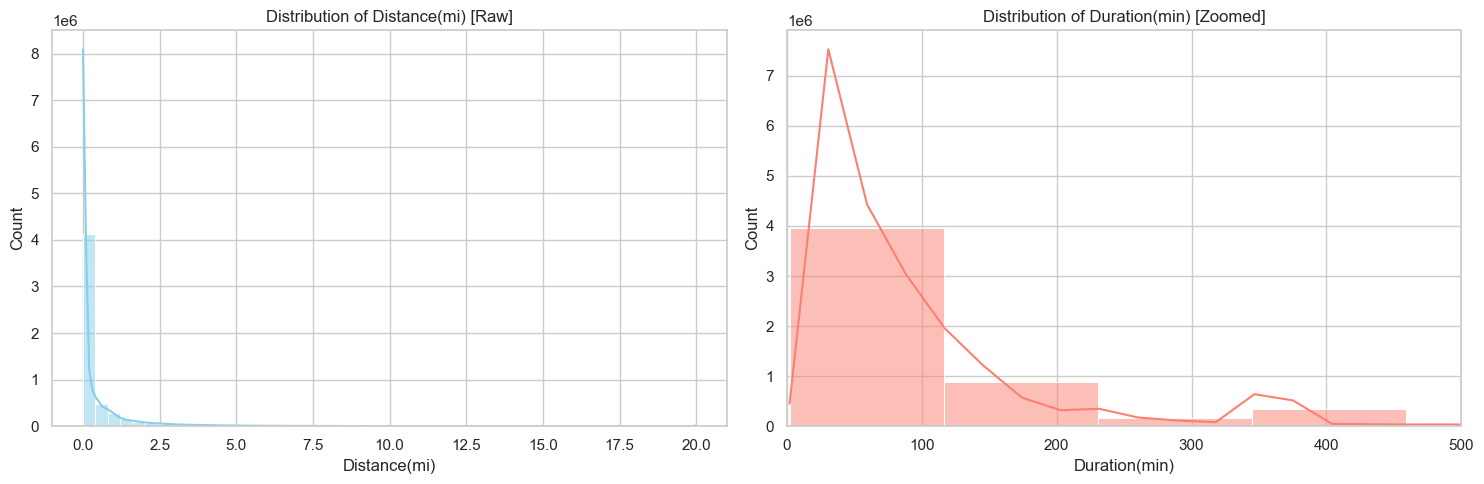

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['Distance(mi)'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Distance(mi) [Raw]')

sns.histplot(df['Duration(min)'], bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_xlim(0, 500) # Zoom in to see the majority
axes[1].set_title('Distribution of Duration(min) [Zoomed]')

plt.tight_layout()
plt.show()

### ข้อสรุปหมวดที่ 1:
1. **Class Imbalance:** ข้อมูล Severity มีความไม่สมดุลอย่างมาก โดยระดับ 2 มีมากกว่า 77% ขณะที่ระดับ 1 มีไม่ถึง 1% การสร้างโมเดลต้องคำนึงถึงเทคนิคจัดการ Imbalance
2. **Skewness:** ทั้ง Duration และ Distance มีความเบ้ขวา (Right-skewed) สูงมาก หมายความว่าอุบัติเหตุส่วนใหญ่ส่งผลกระทบในระยะเวลาและระยะทางสั้นๆ แต่มีส่วนน้อยที่มีค่าสูงมาก (Long-tail) การใช้ Log Transformation ในขั้นตอน Feature Engineering จึงมีความจำเป็น

# หมวดที่ 2: ความสัมพันธ์ระหว่างตัวแปรเป้าหมาย (Relationships Between Targets)
วิเคราะห์ว่าตัวแปรเป้าหมายทั้งสามมีความสัมพันธ์กันอย่างไร เพื่อออกแบบโครงสร้างโมเดล (เช่น Chained Regression)

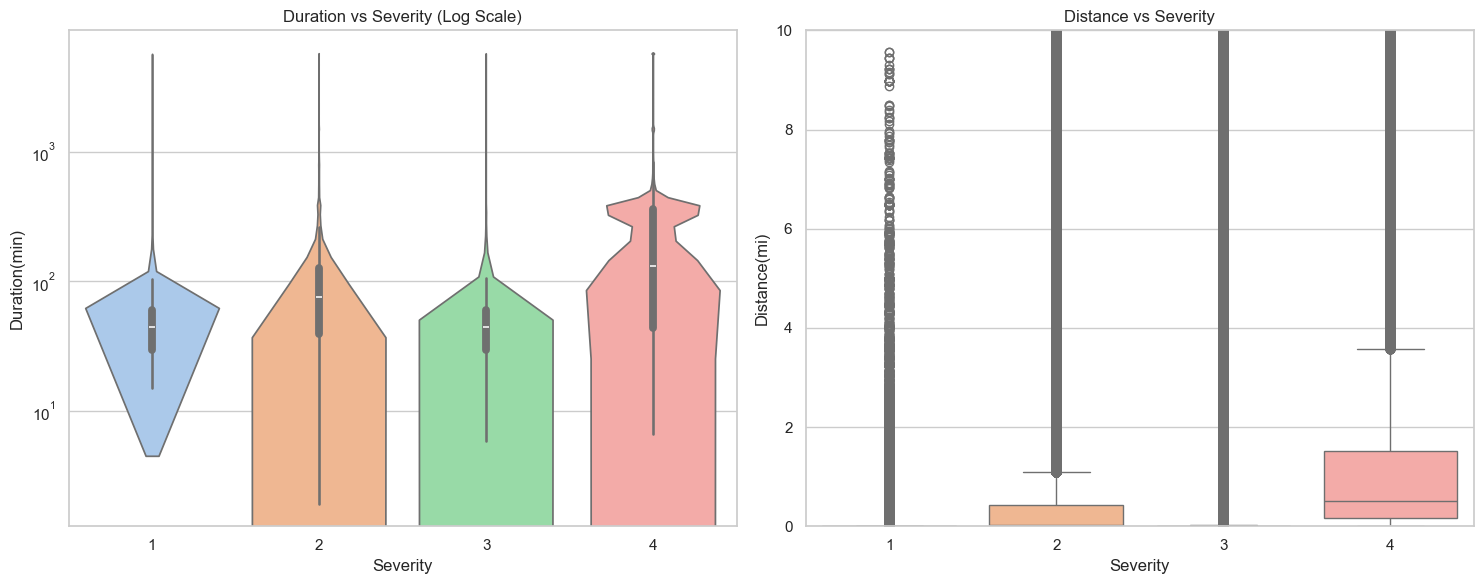

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.violinplot(data=df, x='Severity', y='Duration(min)', ax=axes[0], palette='pastel')
axes[0].set_yscale('log')
axes[0].set_title('Duration vs Severity (Log Scale)')

sns.boxplot(data=df, x='Severity', y='Distance(mi)', ax=axes[1], palette='pastel')
axes[1].set_ylim(0, 10)
axes[1].set_title('Distance vs Severity')

plt.tight_layout()
plt.show()

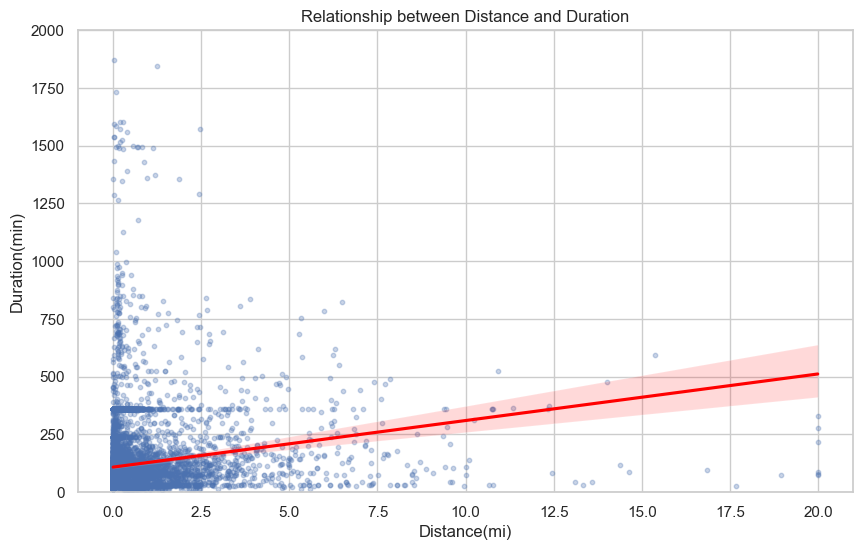

In [6]:
plt.figure(figsize=(10,6))
df_sample = df.sample(n=10000, random_state=42)
sns.regplot(data=df_sample, x='Distance(mi)', y='Duration(min)', 
            scatter_kws={'alpha':0.3,'s':10}, line_kws={'color':'red'})
plt.ylim(0, 2000)
plt.title('Relationship between Distance and Duration')
plt.show()

### ข้อสรุปหมวดที่ 2:
1. **Severity vs Impacts:** อุบัติเหตุระดับ 4 (รุนแรงที่สุด) มีค่ามัธยฐานของทั้ง Duration และ Distance สูงกว่าระดับอื่นอย่างชัดเจน บ่งบอกว่า Severity เป็นตัวแปรต้นที่สำคัญมาก
2. **Chained Relationship:** พบความสัมพันธ์เชิงบวกระหว่าง Distance และ Duration (เมื่อระยะทางที่ได้รับผลกระทบยาวขึ้น ระยะเวลาก็มักจะนานขึ้นตาม) สนับสนุนสมมติฐานการทำ Chained Regression โดยทำนาย Distance ก่อนเพื่อนำไปเป็น Input ของการทำนาย Duration

# หมวดที่ 3: ปัจจัยทางเวลา (Temporal Patterns)
วิเคราะห์แนวโน้มอุบัติเหตุตามช่วงชั่วโมงของวัน และเดือนของปี

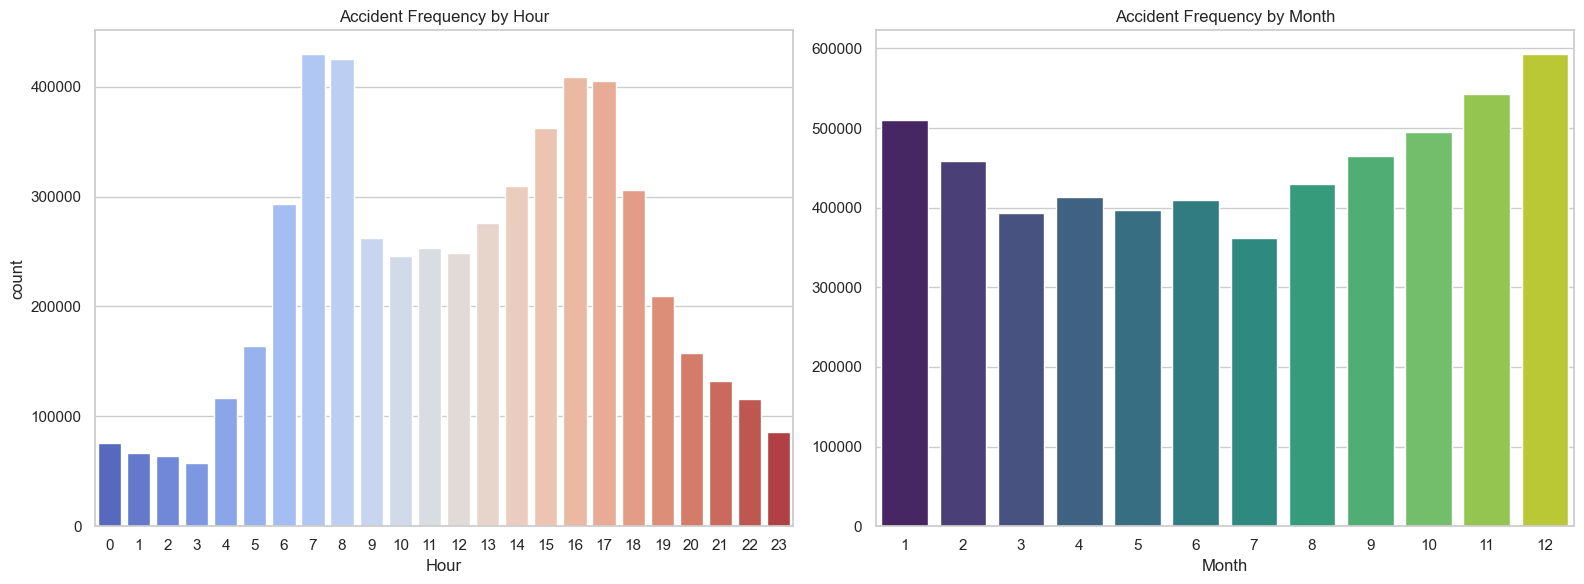

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x='Hour', ax=axes[0], palette='coolwarm')
axes[0].set_title('Accident Frequency by Hour')

month_counts = df['Month'].value_counts().sort_index()
sns.barplot(x=month_counts.index, y=month_counts.values, ax=axes[1], palette='viridis')
axes[1].set_title('Accident Frequency by Month')

plt.tight_layout()
plt.show()

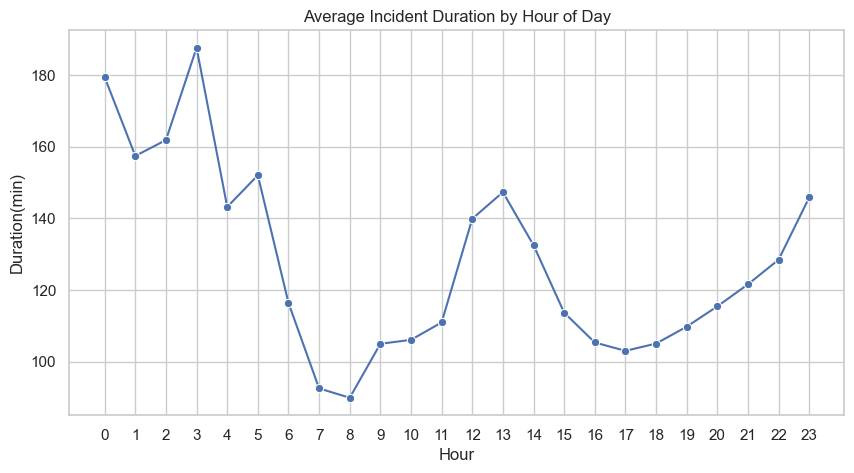

In [8]:
hourly_duration = df.groupby('Hour')['Duration(min)'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_duration, x='Hour', y='Duration(min)', marker='o', color='b')
plt.title('Average Incident Duration by Hour of Day')
plt.xticks(range(0, 24))
plt.show()

### ข้อสรุปหมวดที่ 3:
1. **Rush Hour Frequency:** อุบัติเหตุเกิดขึ้นหนาแน่นที่สุดในช่วงเวลาเร่งด่วน (7.00-9.00 น. และ 15.00-18.00 น.) ตามการจราจรที่หนาแน่น
2. **Nighttime Severity:** แม้ช่วงกลางคืน (0.00-4.00 น.) จะมีจำนวนอุบัติเหตุน้อย แต่กลับมีค่าเฉลี่ย Duration สูงที่สุด อาจเนื่องมาจากอุบัติเหตุในช่วงที่รถโล่งมักมีความเร็วสูงและรุนแรงกว่าปกติ

# หมวดที่ 4: ปัจจัยสภาพอากาศและสิ่งแวดล้อม (Weather & Environment)
วิเคราะห์อิทธิพลของสภาพอากาศ และทัศนวิสัย

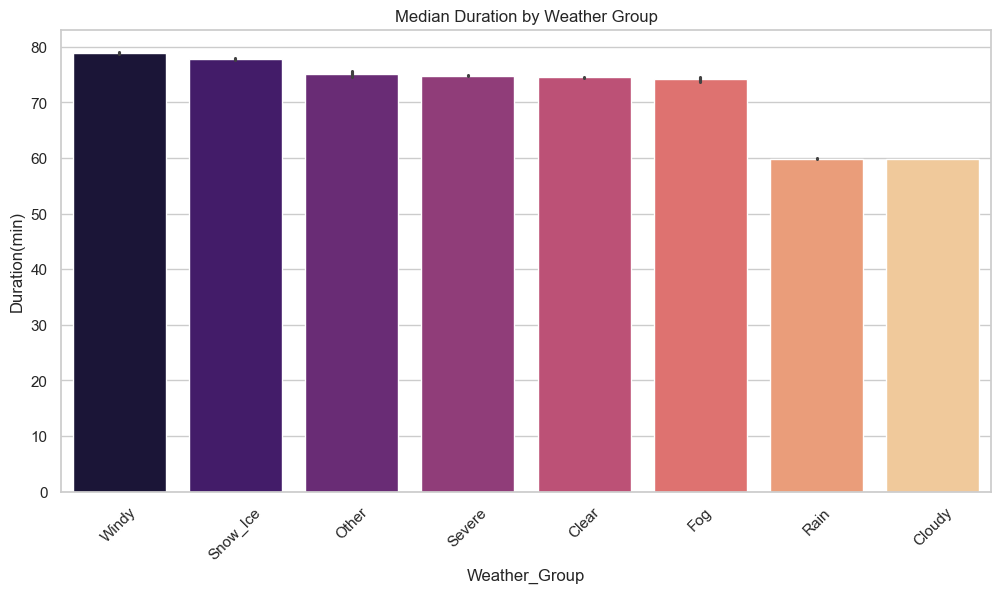

In [9]:
weather_order = df.groupby('Weather_Group')['Duration(min)'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Weather_Group', y='Duration(min)', order=weather_order, estimator=np.median, palette='magma')
plt.title('Median Duration by Weather Group')
plt.xticks(rotation=45)
plt.show()

### ข้อสรุปหมวดที่ 4:
1. **Severe Weather:** สภาพอากาศแบบ Windy, Snow/Ice และ Severe มีผลอย่างชัดเจนในการเพิ่ม Duration ของอุบัติเหตุ
2. **Visibility Factor:** ทัศนวิสัยที่ต่ำส่งผลให้อุบัติเหตุมีความซับซ้อนและใช้เวลาจัดการนานขึ้น ข้อมูล Weather_Group จึงเป็นตัวแปรที่ควรให้ความสำคัญในโมเดล

# หมวดที่ 5: การวิเคราะห์เชิงพื้นที่ (Spatial Analysis)
ดูการกระจายตัวของอุบัติเหตุตามรัฐและตำแหน่งทางภูมิศาสตร์

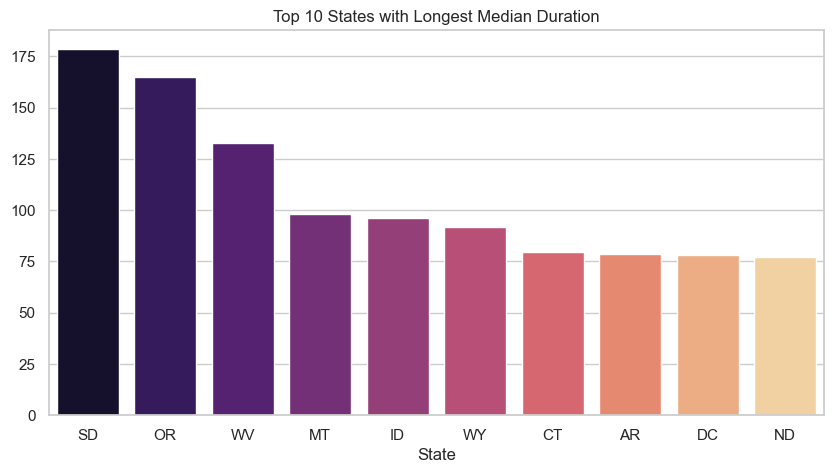

In [10]:
top_states = df.groupby('State')['Duration(min)'].median().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_states.index, y=top_states.values, palette='magma')
plt.title('Top 10 States with Longest Median Duration')
plt.show()

### ข้อสรุปหมวดที่ 5:
1. **Regional Variation:** แต่ละรัฐมีค่ามัธยฐาน Duration ต่างกันอย่างมีนัยสำคัญ ซึ่งอาจสะท้อนถึงประสิทธิภาพการจัดการเหตุฉุกเฉินหรือความหนาแน่นของประชากรในพื้นที่นั้นๆ
2. **Geographic Clustering:** อุบัติเหตุกระจุกตัวอยู่ตามแนวชายฝั่งตะวันออกและตะวันตกเป็นหลัก การใช้ข้อมูลรัฐร่วมกับพิกัดจึงสำคัญ

# หมวดที่ 6: โครงสร้างพื้นฐานถนน (Road Infrastructure)
วิเคราะห์จุดเกิดเหตุใกล้ทางแยก, สัญญาณไฟ หรือจุดสนใจอื่นๆ

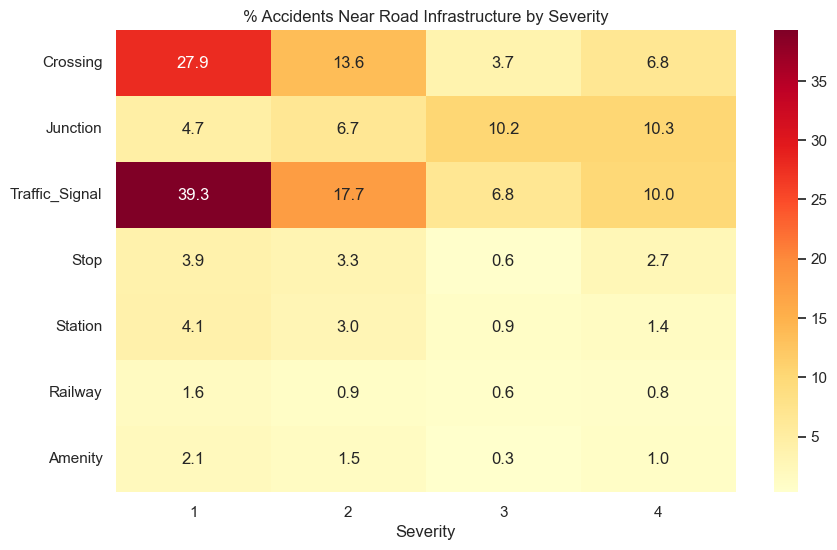

In [11]:
bool_cols = ['Crossing', 'Junction', 'Traffic_Signal', 'Stop', 'Station', 'Railway', 'Amenity']
infra_df = df.groupby('Severity')[bool_cols].mean() * 100

plt.figure(figsize=(10, 6))
sns.heatmap(infra_df.T, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('% Accidents Near Road Infrastructure by Severity')
plt.show()

### ข้อสรุปหมวดที่ 6:
1. **Complexity at Junctions:** อุบัติเหตุระดับความรุนแรงสูงมักสัมพันธ์กับทางแยก (Junction) มากกว่าจุดอื่นๆ
2. **Signal Safety:** จุดที่มีสัญญาณไฟ (Traffic Signal) มักพบอุบัติเหตุระดับ 2 เป็นส่วนใหญ่ ซึ่งอาจเป็นอุบัติเหตุเล็กน้อยจากการหยุดรถ

# หมวดที่ 7: การวิเคราะห์คำสำคัญใน Description (Keyword Analysis)
สกัดคำสำคัญจากคำบรรยายเหตุการณ์ เพื่อดูว่าส่งผลต่อระยะทาง (Distance) และความรุนแรงอย่างไร

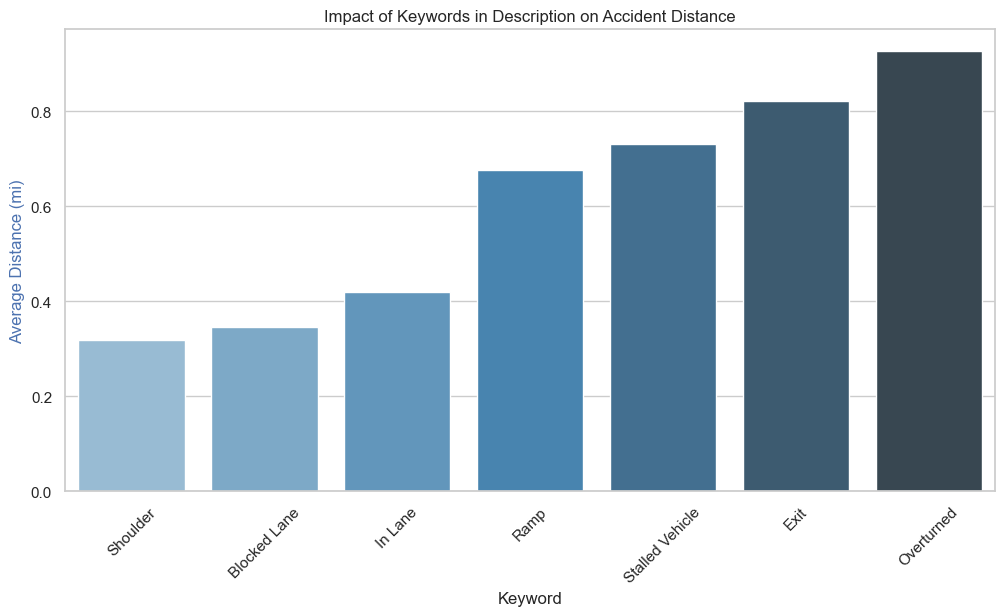

In [12]:
keywords_to_check = {
    'shoulder': 'Shoulder',
    'blocked': 'Blocked Lane',
    'lane': 'In Lane',
    'ramp': 'Ramp',
    'exit': 'Exit',
    'overturned': 'Overturned',
    'stalled': 'Stalled Vehicle'
}

# Sample data for analysis to save time
df_sample_kw = df.sample(n=100000, random_state=42)

keyword_stats = []
for kw, label in keywords_to_check.items():
    mask = df_sample_kw['Description'].str.contains(kw, case=False, na=False)
    avg_dist = df_sample_kw[mask]['Distance(mi)'].mean()
    median_dur = df_sample_kw[mask]['Duration(min)'].median()
    count = mask.sum()
    keyword_stats.append({'Keyword': label, 'Avg_Distance': avg_dist, 'Median_Duration': median_dur, 'Count': count})

df_kw = pd.DataFrame(keyword_stats).sort_values('Avg_Distance')

fig, ax1 = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_kw, x='Keyword', y='Avg_Distance', palette='Blues_d', ax=ax1)
ax1.set_ylabel('Average Distance (mi)', color='b')
ax1.set_title('Impact of Keywords in Description on Accident Distance')
plt.xticks(rotation=45)
plt.show()

### ข้อสรุปหมวดที่ 7:
1. **Shoulder/Side Accidents:** ยืนยันสมมติฐานว่าคำว่า **'shoulder' (ไหล่ทาง/ข้างทาง)** สัมพันธ์กับอุบัติเหตุที่มี **Distance(mi) เข้าใกล้ 0** มากที่สุด เนื่องจากเหตุการณ์เกิดขึ้นนอกช่องทางจราจรหลัก จึงไม่ส่งผลต่อระยะทางบนถนน
2. **Overturned/Blocked:** คำว่า 'overturned' มักสัมพันธ์กับ Distance ที่ยาวกว่า และ Severity ที่สูงกว่า
3. **Feature Engineering Insight:** การทำ Keyword Extraction จาก Description เป็น Feature ที่มีมูลค่าสูงมาก (High Information Gain) โดยเฉพาะคำที่ระบุตำแหน่งที่เกิดเหตุ

# หมวดที่ 8: ความสัมพันธ์เชิงเส้น (Correlation Analysis)
ตรวจสอบความสัมพันธ์ระหว่างตัวแปรตัวเลข

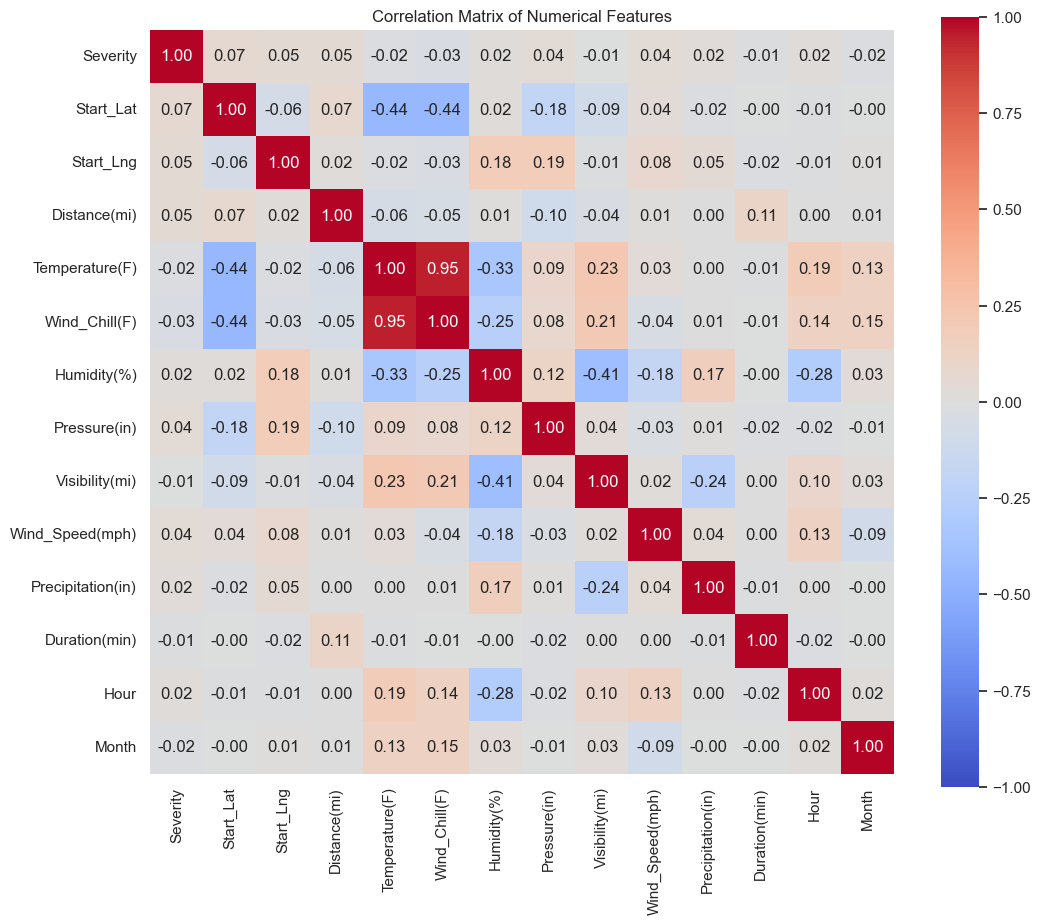

In [13]:
num_cols = df.select_dtypes(include=['float64','int64']).columns
df_num = df[num_cols]

corr_matrix = df_num.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1,vmax=1,square=True)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# หมวดที่ 9: การวิเคราะห์ความเบ้ของข้อมูล (Skewness Analysis)
ตรวจสอบการกระจายตัวของตัวแปรเชิงปริมาณทั้งหมด เพื่อประเมินความจำเป็นในการทำ Data Transformation (เช่น Log Transformation) เพื่อลดความเบ้และทำให้ข้อมูลมีความเป็นปกติ (Normality) มากขึ้น

In [ ]:
# เลือกเฉพาะคอลัมน์ที่เป็นตัวเลข
num_features = df.select_dtypes(include=['float64', 'int64']).columns

# สร้าง Histograms สำหรับทุก Feature เพื่อดูการกระจายตัว
df[num_features].hist(bins=50, figsize=(20, 15), color='skyblue', edgecolor='black', grid=False)
plt.suptitle('Skewness Analysis: Histograms of Numerical Features', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# คำนวณค่า Skewness ประกอบการตัดสินใจ
print("--- Skewness Values ---")
skew_vals = df[num_features].skew().sort_values(ascending=False)
print(skew_vals)

print("\n--- Features suggested for Log Transformation (Skewness > 1 or < -1) ---")
print(skew_vals[(skew_vals > 1) | (skew_vals < -1)].index.tolist())

## บทสรุปภาพรวมจากการทำ EDA (Final Conclusion)

จากการวิเคราะห์ข้อมูลอุบัติเหตุทั้ง 8 หมวด พบประเด็นสำคัญที่ต้องนำไปดำเนินการต่อดังนี้:

1. **Model Strategy:** ควรใช้โครงสร้างแบบ **Chained Model** (ทำนาย Distance -> นำผลไปทำนาย Duration) และใช้เทคนิคจัดการ Class Imbalance สำหรับ Severity
2. **Key Predictive Features:**
   - **Description Keyword:** คำว่า 'shoulder', 'blocked', 'overturned' มีผลต่อ Distance และ Severity อย่างมาก
   - **Temporal Factor:** ช่วงเวลาเร่งด่วนส่งผลต่อความถี่ แต่ช่วงกลางคืนส่งผลต่อความนาน (Duration)
   - **Environmental Factor:** สภาพอากาศเลวร้าย (Severe/Windy) เป็นปัจจัยหลักที่ทำให้เหตุการณ์ล่าช้า
3. **Proposed Feature Engineering:**
   - ทำ **Keyword Extraction** จาก Description
   - สร้าง Feature **Is_Night** และ **Is_Rush_Hour**
   - ทำ **Target Encoding/Frequency Encoding** สำหรับ State และ Weather_Group
   - ใช้ **Log Transformation** สำหรับ Distance และ Duration เพื่อลดความเบ้ของข้อมูล